In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import bayesian_blocks

from Kakapo.photometry import forced_photometry, forced_photometry_psf, psf_wrapper
from Kakapo.cleaning_curve import gauss_smooth

%matplotlib widget

In [2]:
diff_file = '/Users/zgl12/Modules/Kakapo/Data/difference_arrays/c3/diff_c3_t205922648.npy'

diff = np.load(diff_file)

In [3]:
epsf_data = np.genfromtxt('/Users/zgl12/Modules/Kakapo/epsf_data.txt')
epsf_data = epsf_data[2:-2,2:-2]
epsf_data /= np.nansum(epsf_data)

In [4]:
# lc_time = np.load('/Users/zgl12/Modules/Kakapo/lc_time.npy')
# lc_flux = np.load('/Users/zgl12/Modules/Kakapo/lc_flux.npy')
# lc_flux_err = np.load('/Users/zgl12/Modules/Kakapo/lc_flux_err.npy')

# mask = np.isfinite(lc_flux) & np.isfinite(lc_time) & np.isfinite(lc_flux_err)

# masked_lc_time = lc_time[mask]
# masked_lc_flux = lc_flux[mask]
# masked_lc_flux_err = lc_flux_err[mask]

# smoothed_lc_wgt, smooth_err_wgt = gauss_smooth(masked_lc_time, masked_lc_flux, masked_lc_flux_err)
# smoothed_lc, smooth_err = gauss_smooth(masked_lc_time, masked_lc_flux, None)
noise_model = np.load('/Users/zgl12/Modules/Kakapo/noise_model.npy')

In [5]:
lc_flux = forced_photometry(diff, 7.41, 6.12, None, bkg = False)
lc_flux2 = forced_photometry(diff, 7.41, 6.12, None, bkg = True)

psf_flux = psf_wrapper(diff, 7.41, 6.12, epsf_data, noise_model)
# psf_flux = forced_photometry_psf(diff, noise_model, 7.41, 6.12, epsf_data, bkg=False)
lc_psf_flux = forced_photometry(diff, 7.41, 6.12, epsf_data, bkg = False, method = 'psf')
lc_time = np.load('/Users/zgl12/Modules/Kakapo/lc_time.npy')

mask = np.isfinite(lc_flux) & np.isfinite(lc_time) #& np.isfinite(lc_flux_err)

masked_lc_time = lc_time[mask]
masked_lc_flux = lc_flux[mask]
# masked_lc_flux_err = lc_flux_err[mask]

# smoothed_lc, smooth_err = gauss_smooth(masked_lc_time, masked_lc_flux, None)

# smoothed_lc_new, smoothed_lc_new_err, scale = gauss_smooth_weighted(masked_lc_time, masked_lc_flux, masked_lc_flux_err)

In [6]:
psf_flux

(array([ 63.96328377,  67.9344019 ,  63.2583578 , ...,          nan,
                 nan, 482.2216247 ]),
 array([None, None, None, ..., nan, nan, None], dtype=object))

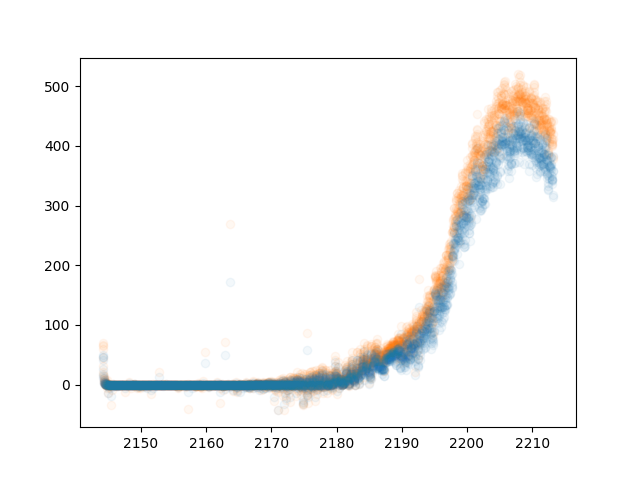

In [7]:
plt.figure()
plt.scatter(masked_lc_time, masked_lc_flux, alpha = 0.05, zorder = 10)
# plt.scatter(masked_lc_time, psf_flux[0][mask], alpha = 0.05)
plt.scatter(masked_lc_time, lc_psf_flux[mask], alpha = 0.05)
# plt.scatter(masked_lc_time, lc_flux2[mask], alpha = 0.05)
# plt.scatter(masked_lc_time, smoothed_lc, alpha = 0.05)
plt.show()

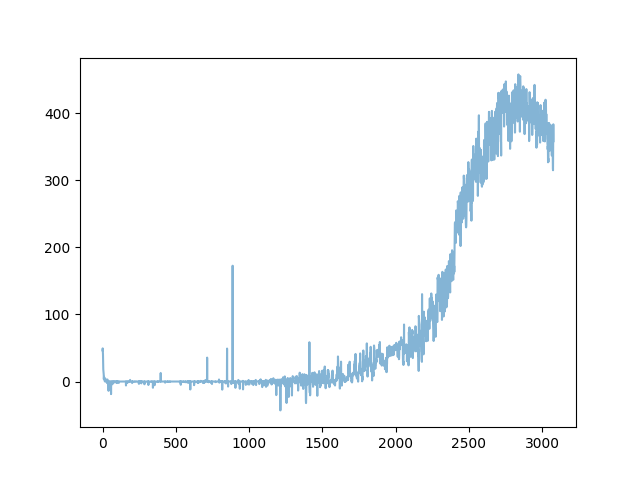

In [8]:
plt.figure()
plt.plot(masked_lc_flux, alpha = 0.55, zorder = 10)
plt.show()